# **2024(R6)年度 機械学習**
# **第12週　強化学習**
## ニューラルネットワークを用いた価値関数の近似(組合せ爆発の対策と連続値への対応)
## 多層パーセプトロン(MLP)
## Deep Q-Network(DQN)
小林 邦和＠愛知県立大学 情報科学部  
作成日: 12/19/2024
>引用元<br>
>久保隆宏(著)「Pythonで学ぶ強化学習-入門から実践まで」講談社(2019)<br>
>https://www.kspub.co.jp/book/detail/5142981.html<br>
>サンプルコード<br>
>https://github.com/icoxfog417/baby-steps-of-rl-ja

# **準備**

## 警告の非表示(必要に応じて実行，Google Colabでは不要)

In [1]:
import warnings
warnings.filterwarnings('ignore')

## Google Driveのマウント(必要に応じて実行)

In [2]:
if str(get_ipython()).startswith("<google.colab."):
    from google.colab import drive
    drive.mount('/content/drive')

## rootディレクトリの指定(必要に応じてディレクトリ名を変更の上，実行)

In [3]:
if str(get_ipython()).startswith("<google.colab."):
    root_dir = '/content/drive/My Drive/Colab Notebooks/4_Machine_Learning_2024/' # 要変更
else:
    root_dir = './'

## 強化学習フレームワーク(必要に応じて実行)

In [4]:
if str(get_ipython()).startswith("<google.colab."):
    !pip install gymnasium

## 日本語化Matplotlib(必要に応じて実行)

In [5]:
# if str(get_ipython()).startswith("<google.colab."):
#     !pip install japanize-matplotlib

## 各種ライブラリの読み込み

In [6]:
import os
import io
import re
import random
import argparse
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import namedtuple
from collections import deque
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib
import tensorflow as tf # 機械学習フレームワーク
import keras as K # 深層学習フレームワーク
import gymnasium as gym # 強化学習フレームワーク
# グラフ表示で日本語を使う場合，以下2行は必須
# import japanize_matplotlib
# japanize_matplotlib.japanize()

## フラグ設定

In [7]:
# エージェントの経験
Experience = namedtuple("Experience", ["s", "a", "r", "n_s", "d"])

# エピソード数
n_episode = 200
# n_episode = 300

# ε-greedy法のランダムな行動選択確率の初期値
epsilon = 0.1
# epsilon = 0.2

# 割引率
gamma = 0.9

# バッファーサイズ
buffer_size = 1024
# buffer_size = 4096

# バッチサイズ
batch_size = 32
# batch_size = 128

# ログ表示の間隔(エピソード)
report_interval = 10
# report_interval = 100

# **ニューラルネットワーク型強化学習フレームワーク**
### スーパークラスNN_Agent・Trainer・Observer・Loggerは書籍(久保,2019)付属のサンプルコードを一部改変して引用

## エージェントのスーパークラスNN_Agent(ニューラルネットワークで実装されたエージェント)

In [8]:
class NN_Agent():
    def __init__(self, epsilon, actions):
        self.epsilon = epsilon
        self.actions = actions
        self.model = None
        self.estimate_probs = False
        self.initialized = False

    def save(self, model_path):
        self.model.save(model_path, overwrite=True, include_optimizer=False)

    @classmethod
    def load(cls, env, model_path, epsilon=0.0001):
        actions = list(range(env.action_space.n))
        agent = cls(epsilon, actions)
        agent.model = K.models.load_model(model_path)
        agent.initialized = True
        return agent

    def initialize(self, experiences):
        raise NotImplementedError("You have to implement initialize method.")

    def estimate(self, s):
        raise NotImplementedError("You have to implement estimate method.")

    def update(self, experiences, gamma):
        raise NotImplementedError("You have to implement update method.")

    def policy(self, s):
        if np.random.random() < self.epsilon or not self.initialized:
            return np.random.randint(len(self.actions))
        else:
            estimates = self.estimate(s)
            if self.estimate_probs:
                action = np.random.choice(self.actions,
                                          size=1, p=estimates)[0]
                return action
            else:
                return np.argmax(estimates)

    def play(self, env, episode_count=5, render=True):
        for e in range(episode_count):
            state, _ = env.reset() # stepの戻り値は2項組に変更された
            done = False
            episode_reward = 0
            while not done:
                if render:
                    env.render()
                action = self.policy(state)
                next_state, reward, done, _, _ = env.step(action) # stepの戻り値は5項組に変更された
                episode_reward += reward
                state = next_state
            else:
                print("Get reward {}.".format(episode_reward))

## 学習器のスーパークラスTrainer(エージェントの学習モジュール）

In [9]:
class Trainer():
    def __init__(self, buffer_size=buffer_size, batch_size=batch_size,
                 gamma=gamma, report_interval=report_interval, log_dir=root_dir):
        self.buffer_size = buffer_size
        self.batch_size = batch_size
        self.gamma = gamma
        self.report_interval = report_interval
        self.logger = Logger(log_dir, self.trainer_name)
        self.experiences = deque(maxlen=buffer_size)
        self.training = False
        self.training_count = 0
        self.reward_log = []

    @property
    def trainer_name(self):
        class_name = self.__class__.__name__
        snaked = re.sub("(.)([A-Z][a-z]+)", r"\1_\2", class_name)
        snaked = re.sub("([a-z0-9])([A-Z])", r"\1_\2", snaked).lower()
        snaked = snaked.replace("_trainer", "")
        return snaked

    def train_loop(self, env, agent, episode=n_episode, initial_count=-1,
                   render=False, observe_interval=0):
        self.experiences = deque(maxlen=self.buffer_size)
        self.training = False
        self.training_count = 0
        self.reward_log = []
        frames = []

        for i in range(episode):
            state, _ = env.reset() # stepの戻り値は2項組に変更された
            done = False
            step_count = 0
            self.episode_begin(i, agent)
            while not done:
                if render:
                    env.render()
                if self.training and observe_interval > 0 and\
                   (self.training_count == 1 or
                    self.training_count % observe_interval == 0):
                    frames.append(state)

                action = agent.policy(state)
                next_state, reward, done, _, _ = env.step(action) # stepの戻り値は5項組に変更された
                experience = Experience(state, action, reward, next_state, done)
                self.experiences.append(experience)
                if not self.training and \
                   len(self.experiences) == self.buffer_size:
                    self.begin_train(i, agent)
                    self.training = True

                self.step(i, step_count, agent, experience)

                state = next_state
                step_count += 1
            else:
                self.episode_end(i, step_count, agent)

                if not self.training and \
                   initial_count > 0 and i >= initial_count:
                    self.begin_train(i, agent)
                    self.training = True

                if self.training:
                    if len(frames) > 0:
                        self.logger.write_image(self.training_count,
                                                frames)
                        frames = []
                    self.training_count += 1

    def episode_begin(self, episode, agent):
        pass

    def begin_train(self, episode, agent):
        pass

    def step(self, episode, step_count, agent, experience):
        pass

    def episode_end(self, episode, step_count, agent):
        pass

    def is_event(self, count, interval):
        return True if count != 0 and count % interval == 0 else False

    def get_recent(self, count):
        recent = range(len(self.experiences) - count, len(self.experiences))
        return [self.experiences[i] for i in recent]

## 観測器のスーパークラスObserver(環境における状態の前処理モジュール)

In [10]:
class Observer():
    def __init__(self, env):
        self._env = env

    @property
    def action_space(self):
        return self._env.action_space

    @property
    def observation_space(self):
        return self._env.observation_space

    def reset(self):
        state, info = self._env.reset()
        return self.transform(state), info

    def render(self):
        self._env.render()

    def step(self, action):
        next_state, reward, done, _, _ = self._env.step(action) # stepの戻り値は5項組に変更された
        return self.transform(next_state), reward, done, _, _

    def transform(self, state):
        raise NotImplementedError("You have to implement transform method.")

## 記録器のスーパークラスLogger(学習経過の記録モジュール)

In [11]:
class Logger():
    def __init__(self, log_dir=root_dir, dir_name=root_dir):
        self.log_dir = log_dir
        if not log_dir:
            self.log_dir = os.path.join(os.path.dirname(__file__), "logs")
        if not os.path.exists(self.log_dir):
            os.mkdir(self.log_dir)

        if dir_name:
            self.log_dir = os.path.join(self.log_dir, dir_name)
            if not os.path.exists(self.log_dir):
                os.mkdir(self.log_dir)

        self._callback = tf.compat.v1.keras.callbacks.TensorBoard(
                            self.log_dir)

    @property
    def writer(self):
        return self._callback.writer

    def set_model(self, model):
        self._callback.set_model(model)

    def path_of(self, file_name):
        return os.path.join(self.log_dir, file_name)

    def describe(self, name, values, episode=-1, step=-1):
        mean = np.round(np.mean(values), 3)
        std = np.round(np.std(values), 3)
        desc = "{} is {} (+/-{})".format(name, mean, std)
        if episode > 0:
            print("At episode {}, {}".format(episode, desc))
        elif step > 0:
            print("At step {}, {}".format(step, desc))

    def plot(self, name, values, interval=10):
        indices = list(range(0, len(values), interval))
        means = []
        stds = []
        for i in indices:
            _values = values[i:(i + interval)]
            means.append(np.mean(_values))
            stds.append(np.std(_values))
        means = np.array(means)
        stds = np.array(stds)
        plt.figure()
        plt.title("{} History".format(name))
        plt.grid()
        plt.fill_between(indices, means - stds, means + stds,
                         alpha=0.1, color="g")
        plt.plot(indices, means, "o-", color="g",
                 label="{} per {} episode".format(name.lower(), interval))
        plt.legend(loc="best")
        plt.show()

    def write(self, index, name, value):
        summary = tf.compat.v1.Summary()
        summary_value = summary.value.add()
        summary_value.tag = name
        summary_value.simple_value = value
        self.writer.add_summary(summary, index)
        self.writer.flush()

    def write_image(self, index, frames):
        # Deal with a 'frames' as a list of sequential gray scaled image.
        last_frames = [f[:, :, -1] for f in frames]
        if np.min(last_frames[-1]) < 0:
            scale = 127 / np.abs(last_frames[-1]).max()
            offset = 128
        else:
            scale = 255 / np.max(last_frames[-1])
            offset = 0
        channel = 1  # gray scale
        tag = "frames_at_training_{}".format(index)
        values = []

        for f in last_frames:
            height, width = f.shape
            array = np.asarray(f * scale + offset, dtype=np.uint8)
            image = Image.fromarray(array)
            output = io.BytesIO()
            image.save(output, format="PNG")
            image_string = output.getvalue()
            output.close()
            image = tf.compat.v1.Summary.Image(
                        height=height, width=width, colorspace=channel,
                        encoded_image_string=image_string)
            value = tf.compat.v1.Summary.Value(tag=tag, image=image)
            values.append(value)

        summary = tf.compat.v1.Summary(value=values)
        self.writer.add_summary(summary, index)
        self.writer.flush()

# **MLPによる価値関数の実装**
### サブクラスValueFunctioAgent・CartPoleObserver・ValueFunctionTrainerは書籍(久保,2019)付属のサンプルコードを一部改変して引用

## ValueFunctionAgent(価値関数をMLPで近似したエージェント)[NN_Agentのサブクラス]

In [12]:
class ValueFunctionAgent(NN_Agent):
    def save(self, model_path):
        joblib.dump(self.model, model_path)

    @classmethod
    def load(cls, env, model_path, epsilon=0.0001):
        actions = list(range(env.action_space.n))
        agent = cls(epsilon, actions)
        agent.model = joblib.load(model_path)
        agent.initialized = True
        return agent

    def initialize(self, experiences):
        scaler = StandardScaler()
        estimator = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=1)
        self.model = Pipeline([("scaler", scaler), ("estimator", estimator)])

        states = np.vstack([e.s for e in experiences])
        self.model.named_steps["scaler"].fit(states)

        # Avoid the predict before fit.
        self.update([experiences[0]], gamma=0)
        self.initialized = True
        print("Done initialization. From now, begin training!")

    def estimate(self, s):
        estimated = self.model.predict(s)[0]
        return estimated

    def _predict(self, states):
        if self.initialized:
            predicteds = self.model.predict(states)
        else:
            size = len(self.actions) * len(states)
            predicteds = np.random.uniform(size=size)
            predicteds = predicteds.reshape((-1, len(self.actions)))
        return predicteds

    def update(self, experiences, gamma):
        states = np.vstack([e.s for e in experiences])
        n_states = np.vstack([e.n_s for e in experiences])

        estimateds = self._predict(states)
        future = self._predict(n_states)

        for i, e in enumerate(experiences):
            reward = e.r
            if not e.d:
                reward += gamma * np.max(future[i])
            estimateds[i][e.a] = reward

        estimateds = np.array(estimateds)
        states = self.model.named_steps["scaler"].transform(states)
        self.model.named_steps["estimator"].partial_fit(states, estimateds)

## CartPoleObserver(CartPole環境の観測状態に対する前処理モジュール)[Observerのサブクラス]

In [13]:
class CartPoleObserver(Observer):
    def transform(self, state):
        return np.array(state).reshape((1, -1))

## ValueFunctionTrainer(エージェントの学習モジュール)[Trainerのサブクラス]

In [14]:
class ValueFunctionTrainer(Trainer):
    def train(self, env, episode_count=n_episode, epsilon=epsilon, initial_count=-1,
              render=False):
        actions = list(range(env.action_space.n))
        agent = ValueFunctionAgent(epsilon, actions)
        self.train_loop(env, agent, episode_count, initial_count, render)
        return agent

    def begin_train(self, episode, agent):
        agent.initialize(self.experiences)

    def step(self, episode, step_count, agent, experience):
        if self.training:
            batch = random.sample(self.experiences, self.batch_size)
            agent.update(batch, self.gamma)

    def episode_end(self, episode, step_count, agent):
        rewards = [e.r for e in self.get_recent(step_count)]
        self.reward_log.append(sum(rewards))

        if self.is_event(episode, self.report_interval):
            recent_rewards = self.reward_log[-self.report_interval:]
            self.logger.describe("reward", recent_rewards, episode=episode)

# **DQNによる価値関数の実装**
### サブクラスValueFunctionAgent・CartPoleObserver・ValueFunctionTrainerは書籍(久保,2019)付属のサンプルコードを一部改変して引用

## DeepQNetworkAgent(価値関数をDQNで近似したエージェント)[NN_Agentのサブクラス]

In [15]:
class DeepQNetworkAgent(NN_Agent):
    def __init__(self, epsilon, actions):
        super().__init__(epsilon, actions)
        self._scaler = None
        self._teacher_model = None

    def initialize(self, experiences, optimizer):
        feature_shape = experiences[0].s.shape
        self.make_model(feature_shape)
        self.model.compile(optimizer, loss="mse")
        self.initialized = True
        print("Done initialization. From now, begin training!")

    def make_model(self, feature_shape):
        normal = K.initializers.glorot_normal()
        model = K.Sequential()
        model.add(K.layers.Conv2D(
            32, kernel_size=8, strides=4, padding="same",
            input_shape=feature_shape, kernel_initializer=normal,
            activation="relu"))
        model.add(K.layers.Conv2D(
            64, kernel_size=4, strides=2, padding="same",
            kernel_initializer=normal,
            activation="relu"))
        model.add(K.layers.Conv2D(
            64, kernel_size=3, strides=1, padding="same",
            kernel_initializer=normal,
            activation="relu"))
        model.add(K.layers.Flatten())
        model.add(K.layers.Dense(256, kernel_initializer=normal,
                                 activation="relu"))
        model.add(K.layers.Dense(len(self.actions),
                                 kernel_initializer=normal))
        self.model = model
        self._teacher_model = K.models.clone_model(self.model)

    def estimate(self, state):
        return self.model.predict(np.array([state]))[0]

    def update(self, experiences, gamma):
        states = np.array([e.s for e in experiences])
        n_states = np.array([e.n_s for e in experiences])

        estimateds = self.model.predict(states)
        future = self._teacher_model.predict(n_states)

        for i, e in enumerate(experiences):
            reward = e.r
            if not e.d:
                reward += gamma * np.max(future[i])
            estimateds[i][e.a] = reward

        loss = self.model.train_on_batch(states, estimateds)
        return loss

    def update_teacher(self):
        self._teacher_model.set_weights(self.model.get_weights())

## DeepQNetworkAgentTest(価値関数をMLPで近似したテスト用エージェント)[NN_Agentのサブクラス]

In [16]:
class DeepQNetworkAgentTest(DeepQNetworkAgent):
    def __init__(self, epsilon, actions):
        super().__init__(epsilon, actions)

    def make_model(self, feature_shape):
        normal = K.initializers.glorot_normal()
        model = K.Sequential()
        model.add(K.layers.Dense(64, input_shape=feature_shape,
                                 kernel_initializer=normal, activation="relu"))
        model.add(K.layers.Dense(len(self.actions), kernel_initializer=normal,
                                 activation="relu"))
        self.model = model
        self._teacher_model = K.models.clone_model(self.model)

## MountainCarObserver(MountainCar環境の観測状態に対する前処理モジュール)[Observerのサブクラス]

In [17]:
class MountainCarObserver(Observer):
    def __init__(self, env, width, height, frame_count):
        super().__init__(env)
        self.width = width
        self.height = height
        self.frame_count = frame_count
        self._frames = deque(maxlen=frame_count)

    def transform(self, state):
        grayed = Image.fromarray(state).convert("L")
        resized = grayed.resize((self.width, self.height))
        resized = np.array(resized).astype("float")
        normalized = resized / 255.0  # scale to 0~1
        if len(self._frames) == 0:
            for i in range(self.frame_count):
                self._frames.append(normalized)
        else:
            self._frames.append(normalized)
        feature = np.array(self._frames)
        # Convert the feature shape (f, w, h) => (h, w, f).
        feature = np.transpose(feature, (1, 2, 0))

        return feature

## DeepQNetworkTrainer(エージェントの学習モジュール)[Trainerのサブクラス]

In [18]:
class DeepQNetworkTrainer(Trainer):
    def __init__(self, buffer_size=50000, batch_size=32,
                 gamma=0.99, initial_epsilon=0.5, final_epsilon=1e-3,
                 learning_rate=1e-3, teacher_update_freq=3, report_interval=10,
                 log_dir=root_dir, file_name=""):
        super().__init__(buffer_size, batch_size, gamma,
                         report_interval, log_dir)
        self.file_name = file_name if file_name else root_dir + "dqn_agent.h5"
        self.initial_epsilon = initial_epsilon
        self.final_epsilon = final_epsilon
        self.learning_rate = learning_rate
        self.teacher_update_freq = teacher_update_freq
        self.loss = 0
        self.training_episode = 0
        self._max_reward = -10

    def train(self, env, episode_count=200, initial_count=200,
              test_mode=False, render=False, observe_interval=100):
        actions = list(range(env.action_space.n))
        if not test_mode:
            agent = DeepQNetworkAgent(1.0, actions)
        else:
            agent = DeepQNetworkAgentTest(1.0, actions)
            observe_interval = 0
        self.training_episode = episode_count

        self.train_loop(env, agent, episode_count, initial_count, render,
                        observe_interval)
        return agent

    def episode_begin(self, episode, agent):
        self.loss = 0

    def begin_train(self, episode, agent):
        optimizer = K.optimizers.Adam(learning_rate=self.learning_rate, clipvalue=1.0)
        agent.initialize(self.experiences, optimizer)
        self.logger.set_model(agent.model)
        agent.epsilon = self.initial_epsilon
        self.training_episode -= episode

    def step(self, episode, step_count, agent, experience):
        if self.training:
            batch = random.sample(self.experiences, self.batch_size)
            self.loss += agent.update(batch, self.gamma)

    def episode_end(self, episode, step_count, agent):
        reward = sum([e.r for e in self.get_recent(step_count)])
        self.loss = self.loss / step_count
        self.reward_log.append(reward)
        if self.training:
            self.logger.write(self.training_count, "loss", self.loss)
            self.logger.write(self.training_count, "reward", reward)
            self.logger.write(self.training_count, "epsilon", agent.epsilon)
            if reward > self._max_reward:
                agent.save(self.logger.path_of(self.file_name))
                self._max_reward = reward
            if self.is_event(self.training_count, self.teacher_update_freq):
                agent.update_teacher()

            diff = (self.initial_epsilon - self.final_epsilon)
            decay = diff / self.training_episode
            agent.epsilon = max(agent.epsilon - decay, self.final_epsilon)

        if self.is_event(episode, self.report_interval):
            recent_rewards = self.reward_log[-self.report_interval:]
            self.logger.describe("reward", recent_rewards, episode=episode)

# **価値関数をMLPで近似したエージェントによる制御**
## 問題設定: CartPole
>https://gymnasium.farama.org/environments/classic_control/cart_pole/

## エージェントの訓練

In [19]:
# 問題設定(CartPole)
env = CartPoleObserver(gym.make("CartPole-v1"))

# 強化学習エージェントのインスタンス化
agent = ValueFunctionTrainer()

# 学習パラメータの保存場所
path = agent.logger.path_of("value_function_agent.pkl")

# エージェントの訓練
trained = agent.train(env)

At episode 10, reward is 17.8 (+/-5.307)
At episode 20, reward is 22.6 (+/-10.716)
At episode 30, reward is 32.4 (+/-23.631)
At episode 40, reward is 21.8 (+/-12.106)
Done initialization. From now, begin training!
At episode 50, reward is 13.0 (+/-6.356)
At episode 60, reward is 9.5 (+/-1.432)
At episode 70, reward is 10.0 (+/-1.265)
At episode 80, reward is 10.5 (+/-1.204)
At episode 90, reward is 10.0 (+/-1.183)
At episode 100, reward is 9.6 (+/-0.8)
At episode 110, reward is 9.6 (+/-0.8)
At episode 120, reward is 10.2 (+/-1.166)
At episode 130, reward is 10.3 (+/-0.458)
At episode 140, reward is 11.3 (+/-2.326)
At episode 150, reward is 10.9 (+/-0.943)
At episode 160, reward is 11.3 (+/-1.487)
At episode 170, reward is 11.0 (+/-1.095)
At episode 180, reward is 11.6 (+/-1.2)
At episode 190, reward is 13.1 (+/-2.211)


## 訓練状況の表示(獲得報酬)

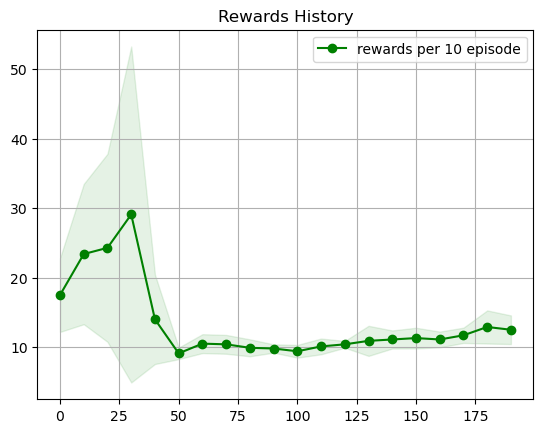

In [20]:
# 訓練状況の表示(獲得報酬)
agent.logger.plot("Rewards", agent.reward_log, agent.report_interval)

# 訓練状況の保存
trained.save(path)

## 学習済エージェントによる制御

In [21]:
# 問題設定(CartPole)
# env = CartPoleObserver(gym.make("CartPole-v1"))

# 学習パラメータの保存場所
# path = agent.logger.path_of("value_function_agent.pkl")

# 学習済パラメータでエージェントのインスタンス化
trained_agent = ValueFunctionAgent.load(env, path)

# 学習済エージェントの動作
trained_agent.play(env)

Get reward 16.0.
Get reward 18.0.
Get reward 23.0.
Get reward 12.0.
Get reward 23.0.


# **価値関数をDQNで近似したエージェントによる制御**
## 問題設定#1: CartPole
>https://gymnasium.farama.org/environments/classic_control/cart_pole/
## 問題設定#2: Mountain Car
>https://gymnasium.farama.org/environments/classic_control/mountain_car/

## エージェントの訓練

In [22]:
# 学習パラメータのファイル名
file_name = "dqn_agent.h5"

# 問題設定(CartPole)
env = gym.make("CartPole-v1")

# 強化学習エージェントのインスタンス化
agent = DeepQNetworkTrainer(file_name=file_name)

# 学習パラメータの保存場所
path = agent.logger.path_of(agent.file_name)

# 学習率
# agent.learning_rate = 1e-4
# agent.learning_rate = 1e-2

# エージェントの訓練
trained = agent.train(env)

At episode 10, reward is 23.7 (+/-14.142)
At episode 20, reward is 23.2 (+/-6.508)
At episode 30, reward is 24.2 (+/-13.34)
At episode 40, reward is 22.6 (+/-11.092)
At episode 50, reward is 19.5 (+/-8.981)
At episode 60, reward is 21.6 (+/-6.086)
At episode 70, reward is 34.0 (+/-14.832)
At episode 80, reward is 18.3 (+/-7.669)
At episode 90, reward is 19.1 (+/-7.489)
At episode 100, reward is 22.6 (+/-20.684)
At episode 110, reward is 19.9 (+/-7.463)
At episode 120, reward is 23.1 (+/-5.839)
At episode 130, reward is 20.5 (+/-10.191)
At episode 140, reward is 18.8 (+/-7.427)
At episode 150, reward is 17.3 (+/-6.373)
At episode 160, reward is 25.1 (+/-11.318)
At episode 170, reward is 20.9 (+/-6.41)
At episode 180, reward is 29.5 (+/-14.514)
At episode 190, reward is 23.0 (+/-6.197)


## 訓練状況の表示(獲得報酬)

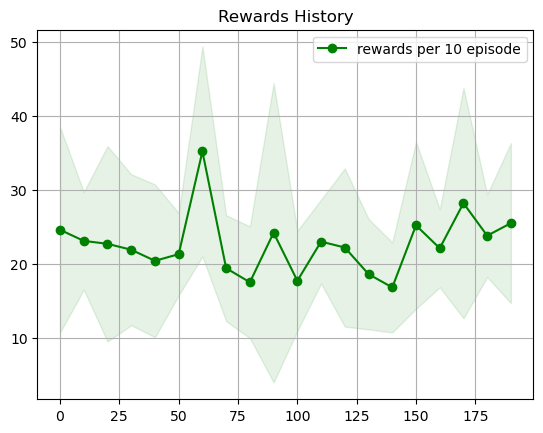

AttributeError: 'NoneType' object has no attribute 'save'

In [23]:
# 訓練状況の表示(獲得報酬)
agent.logger.plot("Rewards", agent.reward_log, agent.report_interval)

# 訓練状況の保存
trained.save(path)

## 学習済エージェントによる制御

In [ ]:
# 学習済パラメータでエージェントのインスタンス化
trained_agent = DeepQNetworkAgentTest.load(env, path)

# 学習済エージェントの動作
trained_agent.play(env, render=True)